# Otimização Multi-Objetivo e NSGA

## Introdução

A otimização multi-objetivo é o processo de encontrar soluções para problemas que envolvem **múltiplos objetivos conflitantes**. Diferentemente da otimização com um único objetivo, aqui não há uma solução única "ótima". Em vez disso, busca-se um conjunto de soluções chamadas de **fronteira de Pareto**, onde nenhuma solução pode ser melhorada em um objetivo sem piorar outro.

Neste notebook, apresentamos um exemplo com dois objetivos aplicados a uma única variável. Trata-se de um caso simples, mas extremamente útil para compreender o funcionamento dos algoritmos **NSGA**. A simplicidade do exemplo permite a visualização geométrica e uma compreensão intuitiva dos resultados, facilitando a análise e a interpretação da fronteira de Pareto gerada.

## Conceitos Fundamentais

### Problema Multiobjetivo

Um problema de otimização multiobjetivo pode ser formalmente descrito como:

$$
\min F(x) = (f_1(x), f_2(x), \dots, f_m(x)), \quad x \in X
$$

onde:
- $X$ representa o espaço de decisão, ou seja, o conjunto de todas as soluções possíveis.
- $F(x)$ é um vetor de $m$ funções objetivo, cada uma $f_i : X \rightarrow \mathbb{R}$, para $i = 1, \dots, m$.
- O objetivo é encontrar um conjunto de soluções ótimas de Pareto, ou seja, soluções onde nenhuma melhora em um objetivo pode ser alcançada sem piorar pelo menos outro objetivo.
- Em geral, um problema pode envolver objetivos de minimização e de maximização. Para simplificar a análise, consideraremos apenas objetivos de minimização, uma vez que qualquer objetivo de maximização pode ser convertido em um objetivo de minimização por meio da negação de sua função.

### Definição: Espaço de Objetivos

Seja $F(x) = (f_1(x), f_2(x), \dots, f_m(x))$ um vetor de $m$ funções objetivo definidas em um domínio $X \subseteq \mathbb{R}^n$, o **espaço de objetivos** é o conjunto de pontos no espaço $\mathbb{R}^m$ alcançáveis pelas funções objetivo quando avaliadas sobre $X$. Isto é:
$$
Y = F(X) = \{ F(x) \in \mathbb{R}^m \mid x \in X \},
$$
onde $Y \subseteq \mathbb{R}^m$ é o espaço de objetivos, e $F(x) = (f_1(x), f_2(x), \dots, f_m(x))$.


### Definição: Solução Dominada

Uma solução $x_1$ *domina* outra solução $x_2$ se for **melhor em todos os objetivos** e **estritamente melhor em pelo menos um objetivo**. Neste caso denotamos $x_1\prec x_2$ e dizemos que $y_2=f(x_2)$ é *dominada* por $y_1=f(x_1)$. Formalmente, para $n$ objetivos podemos denotar:
$$
x_1\prec x_2 \Leftrightarrow 
\begin{cases}
\forall i\in\{1,...,n\} : f_i(x_1)\le f_i(y_2) \\
\exists i\in\{1,...,n\} : f_i(x_1)< f_i(y_2)
\end{cases}
$$

### Definição: Fronteira de Pareto

A *Fronteira de Pareto* é o conjunto de todas as soluções que não são dominadas por nenhuma outra solução.
Formalmente, dado um espaço de decisão $X$ podemos definir o *conjunto eficiente* $X^*$ por:
$$
X^*:=\{x^*\in X^*:x\nprec x^*,\forall x\in X\}
$$
Assim, a *fronteira de Pareto* é a imagem de $X^*$
$$
P:=\{y\in Y:y=f(x),\forall x\in X^*\}
$$
onde $Y$ é o espaço objetivo.


## Exemplo com duas Funções Quadráticas

Vamos considerar um problema simples com duas funções objetivo:

$$
f_1(x) = (x - 2)^2
$$

$$
f_2(x) = (x + 2)^2
$$

queremos encontrar $x$ que minimiza $f_1$ e $f_2$ ao mesmo tempo.

**Análise do Problema**

1. $f_1(x)$: É uma função quadrática que atinge seu mínimo quando $x = 2$.

2. $f_2(x)$: É uma função quadrática que atinge seu mínimo quando $x = -2$.

3. Os objetivos estão em conflito, pois minimizando $f_1(x)$ (levando $x$ para 2) aumentamos $f_2(x)$, e vice-versa.

**Interpretação Geométrica**

- Para valores de $x$ intermediários entre $-2$ e $2$, nenhum dos objetivos é minimizado ao extremo.

- O conjunto de soluções Pareto-ótimas é o intervalo $x \in [-2, 2]$, pois cada ponto nesse intervalo representa um compromisso entre os dois objetivos.


### Espaço de Objetivos do Exemplo
Para o caso específico com:
$$
f_1(x) = (x-2)^2, \quad f_2(x) = (x+2)^2,
$$
e supondo que $x$ pertença a um intervalo $X = [a, b] \subset \mathbb{R}$, o espaço de objetivos é dado por:
$$
F = \{ (f_1(x), f_2(x)) \mid x \in [a, b] \},
$$
com $f_1: X \to \mathbb{R}$ e $f_2: X \to \mathbb{R}$. Em termos de notação, o espaço objetivo $F$ pode ser representado como $f_1 \times f_2 \subseteq \mathbb{R}^2$, significando que ele é um subconjunto do plano $\mathbb{R}^2$, formado pelas imagens de $f_1(x)$ e $f_2(x)$ para $x \in X$.


O código a seguir realiza o plot dos gráficos das funções objetivo $f_1$ e $f_2$ no espaço de decisão e a correspondente fronteira de Pareto no espaço de objetivos.  

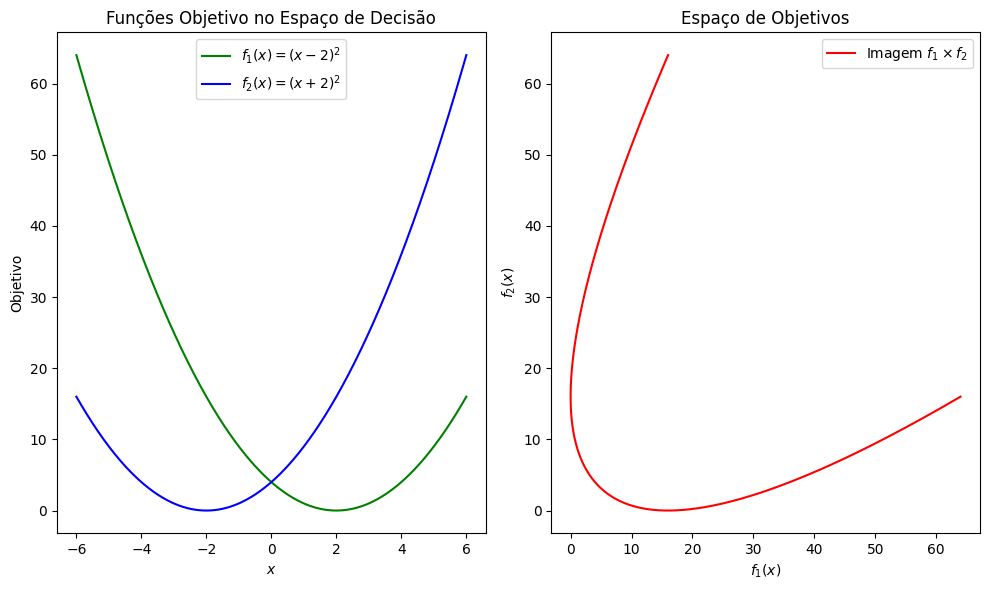

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Definindo as funções objetivo
def f1(x):
    return (x - 2)**2

def f2(x):
    return (x + 2)**2

x = np.linspace(-6, 6, 500)
f1_vals = f1(x)
f2_vals = f2(x)


# Plotando os gráficos
plt.figure(figsize=(10, 6))

# Curva de Pareto no espaço de decisão (x)
plt.subplot(1, 2, 1)
plt.plot(x, f1_vals, label='$f_1(x) = (x-2)^2$', color='green')
plt.plot(x, f2_vals, label='$f_2(x) = (x+2)^2$', color='blue')
plt.title("Funções Objetivo no Espaço de Decisão")
plt.xlabel("$x$")
plt.ylabel("Objetivo")
plt.legend()

# Fronteira de Pareto no espaço de objetivos
plt.subplot(1, 2, 2)
plt.plot(f1_vals, f2_vals, label='Imagem $f_1\\times f_2$', color='red')
plt.title("Espaço de Objetivos")
plt.xlabel("$f_1(x)$")
plt.ylabel("$f_2(x)$")
plt.legend()

plt.tight_layout()
plt.show()

Agora observe que os pontos extremos das funções objetivo, delimitam a fronteira de Pareto. A seguir apresentamos um plot indicando estes pontos no espçao de decisão e no espaço de  objetivos.

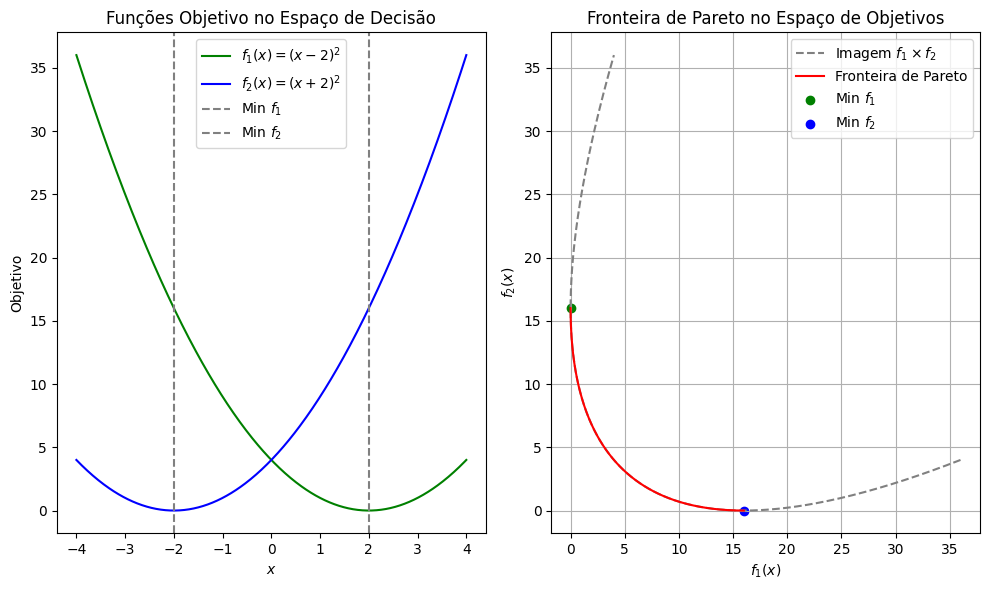

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Definindo as funções objetivo
def f1(x):
    return (x - 2)**2

def f2(x):
    return (x + 2)**2

# Valores de x
x = np.linspace(-4, 4, 500)
f1_vals = f1(x)
f2_vals = f2(x)

y = np.linspace(-2, 2, 500)
pareto_f1_vals = f1(y)
pareto_f2_vals = f2(y)

# Plotando os gráficos
plt.figure(figsize=(10, 6))

# Curva de Pareto no espaço de decisão (x)
plt.subplot(1, 2, 1)
plt.plot(x, f1_vals, label='$f_1(x) = (x-2)^2$', color='green')
plt.plot(x, f2_vals, label='$f_2(x) = (x+2)^2$', color='blue')
plt.axvline(-2, linestyle='--', color='gray', label='Min $f_1$')
plt.axvline(2, linestyle='--', color='gray', label='Min $f_2$')
plt.title("Funções Objetivo no Espaço de Decisão")
plt.xlabel("$x$")
plt.ylabel("Objetivo")
plt.legend()

# Fronteira de Pareto no espaço de objetivos
plt.subplot(1, 2, 2)
plt.plot(f1_vals, f2_vals, linestyle='--', label='Imagem $f_1\\times f_2$', color='gray')
plt.plot(pareto_f1_vals, pareto_f2_vals, label="Fronteira de Pareto", color='red')
plt.scatter(f1(2), f2(2), color='green', label='Min $f_1$')
plt.scatter(f1(-2), f2(-2), color='blue', label='Min $f_2$')
plt.title("Fronteira de Pareto no Espaço de Objetivos")
plt.xlabel("$f_1(x)$")
plt.ylabel("$f_2(x)$")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

Como ambos os objetivos são de **minimização**, a região dominada por um ponto $\mathbf{p}=(p_1,p_2)$ corresponde aos pontos localizados à sua direita e acima:

$$
\mathcal{D}(\mathbf{p})=
\{
z\in\mathbb{R}^2:
z_1\geq p_1,;
z_2\geq p_2
\}.
$$

O código abaixo destaca as regiões dominadas pelos dois extremos da fronteira e pelo ponto intermediário associado a (x=0):

Os três pontos destacados são:

$$
F(-2)=(16,0),\qquad
F(0)=(4,4),\qquad
F(2)=(0,16).
$$

Assim, por exemplo, a região dominada pelo ponto intermediário é

$$
\mathcal{D}(F(0))=
\{
(z_1,z_2):z_1\geq 4,;z_2\geq 4
\}.
$$

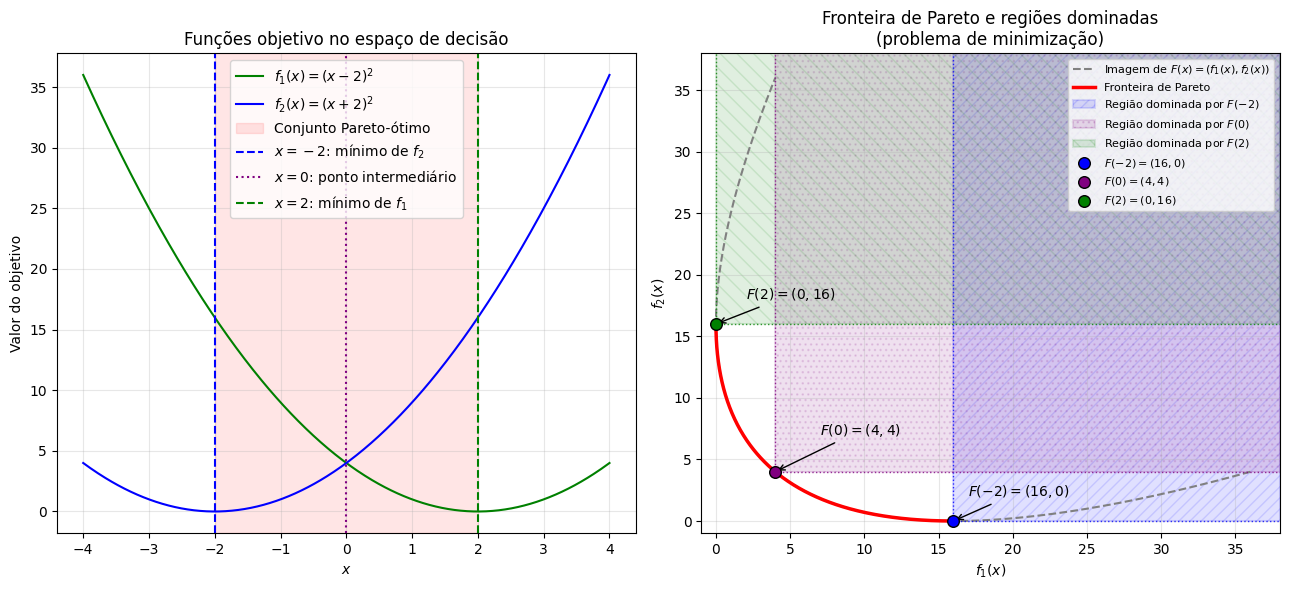

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def f1(x):
    return (x - 2) ** 2

def f2(x):
    return (x + 2) ** 2


x = np.linspace(-4, 4, 500)

f1_vals = f1(x)
f2_vals = f2(x)

# Para este problema, as soluções Pareto-ótimas estão no intervalo [-2, 2].
x_pareto = np.linspace(-2, 2, 500)

pareto_f1_vals = f1(x_pareto)
pareto_f2_vals = f2(x_pareto)

# Extremo que minimiza f2.
x_left = -2
point_left = (f1(x_left), f2(x_left))

# Ponto intermediário da fronteira.
x_middle = 0
point_middle = (f1(x_middle), f2(x_middle))

# Extremo que minimiza f1.
x_right = 2
point_right = (f1(x_right), f2(x_right))

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

ax_decision = axes[0]

ax_decision.plot(
    x,
    f1_vals,
    label=r"$f_1(x)=(x-2)^2$",
    color="green",
)

ax_decision.plot(
    x,
    f2_vals,
    label=r"$f_2(x)=(x+2)^2$",
    color="blue",
)

ax_decision.axvspan(
    -2,
    2,
    alpha=0.10,
    color="red",
    label="Conjunto Pareto-ótimo",
)

ax_decision.axvline(
    -2,
    linestyle="--",
    color="blue",
    label=r"$x=-2$: mínimo de $f_2$",
)

ax_decision.axvline(
    0,
    linestyle=":",
    color="purple",
    label=r"$x=0$: ponto intermediário",
)

ax_decision.axvline(
    2,
    linestyle="--",
    color="green",
    label=r"$x=2$: mínimo de $f_1$",
)

ax_decision.set_title("Funções objetivo no espaço de decisão")
ax_decision.set_xlabel(r"$x$")
ax_decision.set_ylabel("Valor do objetivo")
ax_decision.grid(alpha=0.3)
ax_decision.legend()

ax_objective = axes[1]

ax_objective.plot(
    f1_vals,
    f2_vals,
    linestyle="--",
    color="gray",
    label=r"Imagem de $F(x)=(f_1(x),f_2(x))$",
)

ax_objective.plot(
    pareto_f1_vals,
    pareto_f2_vals,
    linewidth=2.5,
    color="red",
    label="Fronteira de Pareto",
)

# Limites escolhidos antes da criação das regiões dominadas.
objective_max = max(
    np.max(f1_vals),
    np.max(f2_vals),
) + 2

ax_objective.set_xlim(-1, objective_max)
ax_objective.set_ylim(-1, objective_max)


def add_dominated_region(
    ax,
    point,
    color,
    label,
    hatch=None,
):
    """
    Adiciona a região dominada pelo ponto no caso de minimização.

    Um ponto p = (p1, p2) domina todos os pontos z = (z1, z2)
    tais que z1 >= p1 e z2 >= p2, com pelo menos uma desigualdade
    estrita.
    """
    p1, p2 = point

    region = Rectangle(
        (p1, p2),
        objective_max - p1,
        objective_max - p2,
        facecolor=color,
        edgecolor=color,
        alpha=0.12,
        hatch=hatch,
        linewidth=1.5,
        label=label,
        zorder=1,
    )

    ax.add_patch(region)

    # Linhas auxiliares que identificam o vértice da região.
    ax.plot(
        [p1, objective_max],
        [p2, p2],
        linestyle=":",
        color=color,
        alpha=0.8,
        linewidth=1,
    )

    ax.plot(
        [p1, p1],
        [p2, objective_max],
        linestyle=":",
        color=color,
        alpha=0.8,
        linewidth=1,
    )


# Regiões dominadas pelos pontos selecionados.
add_dominated_region(
    ax_objective,
    point_left,
    color="blue",
    label=r"Região dominada por $F(-2)$",
    hatch="///",
)

add_dominated_region(
    ax_objective,
    point_middle,
    color="purple",
    label=r"Região dominada por $F(0)$",
    hatch="...",
)

add_dominated_region(
    ax_objective,
    point_right,
    color="green",
    label=r"Região dominada por $F(2)$",
    hatch="\\\\",
)

# Pontos selecionados.
ax_objective.scatter(
    *point_left,
    color="blue",
    s=70,
    edgecolor="black",
    zorder=5,
    label=r"$F(-2)=(16,0)$",
)

ax_objective.scatter(
    *point_middle,
    color="purple",
    s=70,
    edgecolor="black",
    zorder=5,
    label=r"$F(0)=(4,4)$",
)

ax_objective.scatter(
    *point_right,
    color="green",
    s=70,
    edgecolor="black",
    zorder=5,
    label=r"$F(2)=(0,16)$",
)

# Anotações.
ax_objective.annotate(
    r"$F(-2)=(16,0)$",
    xy=point_left,
    xytext=(17, 2),
    arrowprops={"arrowstyle": "->"},
)

ax_objective.annotate(
    r"$F(0)=(4,4)$",
    xy=point_middle,
    xytext=(7, 7),
    arrowprops={"arrowstyle": "->"},
)

ax_objective.annotate(
    r"$F(2)=(0,16)$",
    xy=point_right,
    xytext=(2, 18),
    arrowprops={"arrowstyle": "->"},
)

ax_objective.set_title(
    "Fronteira de Pareto e regiões dominadas\n"
    "(problema de minimização)"
)

ax_objective.set_xlabel(r"$f_1(x)$")
ax_objective.set_ylabel(r"$f_2(x)$")
ax_objective.grid(alpha=0.3)
ax_objective.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()

## Introdução ao NSGA (Non-dominated Sorting Genetic Algorithm)

O **NSGA** (*Non-dominated Sorting Genetic Algorithm*) é um algoritmo evolutivo desenvolvido para problemas de otimização multiobjetivo. Seu objetivo é encontrar, em uma única execução, um conjunto diversificado de soluções que forneça uma boa aproximação da **fronteira de Pareto**.

Assim como outros algoritmos genéticos, o NSGA evolui uma população de soluções por meio de mecanismos de seleção, cruzamento e mutação. Sua principal contribuição consiste em incorporar ao processo evolutivo dois critérios específicos da otimização multiobjetivo:

1. a classificação das soluções em fronteiras não dominadas;
2. a preservação da diversidade por meio de *fitness sharing*.

Embora tenha sido posteriormente sucedido pelo **NSGA-II**, o NSGA introduziu conceitos fundamentais que permanecem presentes em diversos algoritmos evolutivos multiobjetivo.

### Funcionamento do NSGA

1. **Inicialização da população**

   * Gera-se aleatoriamente uma população inicial de tamanho (N).
   * Cada indivíduo representa uma solução no espaço de decisão.
   * Todos os indivíduos são avaliados nas funções objetivo do problema.

2. **Ordenação não dominada**

   * A população é separada em sucessivas fronteiras de dominância:

     * **Primeira fronteira**: contém as soluções que não são dominadas por nenhuma outra solução da população;
     * **Segunda fronteira**: contém as soluções que se tornam não dominadas após a remoção da primeira fronteira;
     * **Fronteiras seguintes**: são construídas repetindo-se o mesmo procedimento.
   * Cada indivíduo recebe, portanto, um nível ou *rank* de dominância. Quanto menor o rank, melhor é sua posição no processo de seleção.

3. **Atribuição da aptidão**

   * Os indivíduos da primeira fronteira recebem os maiores valores de aptidão.
   * As fronteiras seguintes recebem valores progressivamente menores, garantindo que soluções de uma fronteira superior tenham preferência sobre soluções pertencentes a fronteiras inferiores.
   * Dessa forma, soluções menos dominadas possuem maior probabilidade de participar da reprodução.

4. **Preservação da diversidade por *fitness sharing***

   * Dentro de cada fronteira, calcula-se a proximidade entre os indivíduos.
   * Soluções localizadas em regiões muito densas têm sua aptidão reduzida, enquanto soluções mais isoladas mantêm maior potencial reprodutivo.
   * Esse mecanismo, denominado *fitness sharing*, busca distribuir as soluções ao longo da fronteira de Pareto e evitar que a população se concentre em uma pequena região do espaço de objetivos.
   * Diferentemente do NSGA-II, o NSGA original não utiliza *crowding distance*.

5. **Seleção dos pais**

   * A seleção é realizada com base na aptidão ajustada.
   * Indivíduos pertencentes às melhores fronteiras tendem a aparecer mais vezes no conjunto de reprodução.
   * Dentro de uma mesma fronteira, o *fitness sharing* favorece indivíduos localizados em regiões menos densamente ocupadas.

6. **Aplicação dos operadores genéticos**

   * **Cruzamento**: combina características de dois indivíduos selecionados para produzir novos descendentes.
   * **Mutação**: introduz pequenas alterações aleatórias nos descendentes, aumentando a variabilidade da população e permitindo a exploração de novas regiões do espaço de decisão.

7. **Substituição da população**

   * Os descendentes produzidos formam a população da geração seguinte.
   * Na implementação didática apresentada, ocorre uma substituição geracional: a população anterior é substituída pela nova população.
   * Portanto, não é realizada a união elitista entre pais e descendentes, mecanismo que será introduzido posteriormente no NSGA-II.

8. **Iteração**

   * O processo de avaliação, ordenação não dominada, atribuição de aptidão, seleção, cruzamento e mutação é repetido durante várias gerações.
   * Ao longo da evolução, espera-se que a população se aproxime progressivamente da fronteira de Pareto, mantendo uma distribuição razoavelmente diversificada de soluções.

Para fins didáticos, apresentamos a seguir uma implementação simplificada do NSGA. Ela conserva os principais elementos conceituais do algoritmo original — ordenação não dominada, atribuição de aptidão por fronteiras, *fitness sharing* e seleção proporcional —, mas emprega operadores genéticos simples e uma representação composta por apenas uma variável de decisão.

Embora essa implementação não seja adequada para problemas complexos, de alta dimensão ou de grande escala, ela é suficiente para ilustrar o funcionamento do algoritmo e obter boas aproximações da fronteira de Pareto em problemas pequenos, como o exemplo formado por duas funções objetivo quadráticas.

In [23]:
import math
import random
import numpy as np


def nsga(
    pop_size,
    generations,
    bounds,
    mutation_rate=0.2,
    mutation_scale=0.05,
    sigma_share=0.10,
    alpha_share=2.0,
):
    """
    Implementação didática do NSGA original (NSGA-I).

    Características:
    - ordenação em fronteiras não dominadas;
    - atribuição de aptidão baseada no rank de dominância;
    - fitness sharing para preservação da diversidade;
    - seleção por remainder stochastic sampling;
    - substituição geracional sem elitismo;
    - não utiliza crowding distance.

    Parâmetros
    ----------
    pop_size : int
        Número de indivíduos da população.

    generations : int
        Número de gerações.

    bounds : tuple[float, float]
        Limites inferior e superior da variável de decisão.

    mutation_rate : float
        Probabilidade de mutação de cada descendente.

    mutation_scale : float
        Intensidade máxima da mutação, expressa como fração do
        intervalo da variável de decisão.

    sigma_share : float
        Raio de compartilhamento normalizado no espaço de decisão.

    alpha_share : float
        Expoente da função de compartilhamento.
    """

    lower_bound, upper_bound = bounds
    decision_range = upper_bound - lower_bound

    if pop_size < 2:
        raise ValueError("pop_size deve ser pelo menos 2.")

    if decision_range <= 0:
        raise ValueError("O limite superior deve ser maior que o inferior.")

    if sigma_share <= 0:
        raise ValueError("sigma_share deve ser positivo.")

    # ── Inicialização ──────────────────────────────────────────────────────────

    def initialize_population(size):
        return [
            random.uniform(lower_bound, upper_bound)
            for _ in range(size)
        ]

    # ── Avaliação ──────────────────────────────────────────────────────────────

    def evaluate_population(population):
        return [
            (f1(individual), f2(individual))
            for individual in population
        ]

    # ── Dominância de Pareto ───────────────────────────────────────────────────

    def dominates(objectives_a, objectives_b):
        """
        Retorna True quando A domina B em um problema de minimização.

        A deve:
        - não ser pior que B em nenhum objetivo;
        - ser estritamente melhor em pelo menos um objetivo.
        """
        no_worse = all(
            a <= b
            for a, b in zip(objectives_a, objectives_b)
        )

        strictly_better = any(
            a < b
            for a, b in zip(objectives_a, objectives_b)
        )

        return no_worse and strictly_better

    # ── Ordenação não dominada ─────────────────────────────────────────────────

    def nondominated_sort(objectives):
        """
        Separa os indivíduos em fronteiras não dominadas.

        fronts[0] contém as melhores soluções, isto é, as soluções
        não dominadas da população atual.

        fronts[1] contém as soluções dominadas apenas pelas soluções
        removidas em fronts[0], e assim sucessivamente.
        """
        remaining = list(range(len(objectives)))
        fronts = []

        while remaining:
            current_front = []

            for p in remaining:
                is_dominated = any(
                    q != p and dominates(objectives[q], objectives[p])
                    for q in remaining
                )

                if not is_dominated:
                    current_front.append(p)

            if not current_front:
                raise RuntimeError(
                    "Não foi possível construir a próxima fronteira."
                )

            fronts.append(current_front)

            current_front_set = set(current_front)

            remaining = [
                index
                for index in remaining
                if index not in current_front_set
            ]

        return fronts

    # ── Fitness sharing ────────────────────────────────────────────────────────

    def normalized_distance(individual_a, individual_b):
        """
        Distância normalizada no espaço de decisão.

        Como o problema possui uma única variável, a distância
        corresponde ao valor absoluto da diferença entre os indivíduos.
        """
        return abs(individual_a - individual_b) / decision_range

    def sharing_function(distance):
        """
        Função de compartilhamento:

                     alpha_share
        1 - (d / sigma_share)       se d < sigma_share
        0                           caso contrário
        """
        if distance >= sigma_share:
            return 0.0

        return 1.0 - (
            distance / sigma_share
        ) ** alpha_share

    def assign_shared_fitness(population, fronts):
        """
        Atribui uma aptidão artificial a cada indivíduo.

        A aptidão de uma fronteira é sempre menor que a menor aptidão
        compartilhada da fronteira anterior. Consequentemente, qualquer
        indivíduo de uma fronteira melhor possui prioridade sobre os
        indivíduos das fronteiras seguintes.
        """
        fitness = [0.0] * len(population)

        # Valor inicial alto para a primeira fronteira.
        dummy_fitness = float(pop_size)

        for front in fronts:
            niche_counts = {}

            for i in front:
                niche_count = sum(
                    sharing_function(
                        normalized_distance(
                            population[i],
                            population[j],
                        )
                    )
                    for j in front
                )

                niche_counts[i] = max(niche_count, 1.0e-12)

            # Aptidão compartilhada: indivíduos em regiões densas
            # recebem menor aptidão.
            for i in front:
                fitness[i] = (
                    dummy_fitness / niche_counts[i]
                )

            # A próxima fronteira deve possuir aptidão estritamente
            # inferior à menor aptidão da fronteira atual.
            minimum_front_fitness = min(
                fitness[i] for i in front
            )

            dummy_fitness = max(
                minimum_front_fitness - 1.0e-12,
                1.0e-12,
            )

        return fitness

    # ── Seleção ────────────────────────────────────────────────────────────────

    def stochastic_remainder_selection(fitness):
        """
        Constrói uma população de pais proporcionalmente à aptidão.

        A parte inteira do número esperado de cópias é inserida
        diretamente. As posições restantes são preenchidas de acordo
        com as partes fracionárias.

        Indivíduos pertencentes às melhores fronteiras recebem maior
        aptidão e, consequentemente, mais cópias no conjunto de pais.
        """
        total_fitness = sum(fitness)

        if total_fitness <= 0:
            raise RuntimeError("A aptidão total deve ser positiva.")

        expected_copies = [
            pop_size * value / total_fitness
            for value in fitness
        ]

        mating_pool = []

        fractional_parts = []

        for index, expected in enumerate(expected_copies):
            integer_copies = math.floor(expected)

            mating_pool.extend(
                [index] * integer_copies
            )

            fractional_parts.append(
                expected - integer_copies
            )

        remaining_positions = pop_size - len(mating_pool)

        if remaining_positions > 0:
            fractional_sum = sum(fractional_parts)

            # Proteção contra erros numéricos.
            weights = (
                fractional_parts
                if fractional_sum > 0
                else fitness
            )

            selected = random.choices(
                population=range(len(fitness)),
                weights=weights,
                k=remaining_positions,
            )

            mating_pool.extend(selected)

        # Coloca primeiro os pais de maior aptidão.
        mating_pool.sort(
            key=lambda index: fitness[index],
            reverse=True,
        )

        return mating_pool

    # ── Operadores genéticos ───────────────────────────────────────────────────

    def crossover(parent1, parent2):
        """
        Cruzamento aritmético.

        São produzidos dois descendentes complementares.
        """
        beta = random.random()

        child1 = (
            beta * parent1
            + (1.0 - beta) * parent2
        )

        child2 = (
            (1.0 - beta) * parent1
            + beta * parent2
        )

        return child1, child2

    def mutate(individual):
        """
        Adiciona uma perturbação uniforme e mantém o indivíduo
        dentro dos limites do problema.
        """
        if random.random() < mutation_rate:
            maximum_step = mutation_scale * decision_range

            individual += random.uniform(
                -maximum_step,
                maximum_step,
            )

        return float(
            np.clip(
                individual,
                lower_bound,
                upper_bound,
            )
        )

    # ── Evolução ───────────────────────────────────────────────────────────────

    population = initialize_population(pop_size)

    for generation in range(generations):
        objectives = evaluate_population(population)

        fronts = nondominated_sort(objectives)

        shared_fitness = assign_shared_fitness(
            population,
            fronts,
        )

        mating_pool = stochastic_remainder_selection(
            shared_fitness
        )

        offspring = []

        # Os índices estão ordenados por aptidão: os indivíduos das
        # melhores fronteiras aparecem primeiro e possuem mais cópias.
        for position in range(0, pop_size, 2):
            parent1_index = mating_pool[position]

            parent2_index = mating_pool[
                (position + 1) % pop_size
            ]

            parent1 = population[parent1_index]
            parent2 = population[parent2_index]

            child1, child2 = crossover(
                parent1,
                parent2,
            )

            offspring.append(mutate(child1))

            if len(offspring) < pop_size:
                offspring.append(mutate(child2))

        # NSGA-I geracional: a população anterior é substituída.
        population = offspring

    # ── Resultado final ────────────────────────────────────────────────────────

    objectives = evaluate_population(population)
    fronts = nondominated_sort(objectives)

    pareto_front = [
        objectives[index]
        for index in fronts[0]
    ]

    pareto_front.sort(
        key=lambda point: point[0]
    )

    return pareto_front

A seguir, apresentamos o resultado da execução do algoritmo, com os pontos obtidos sobrepostos à curva correspondente à fronteira de Pareto exata.

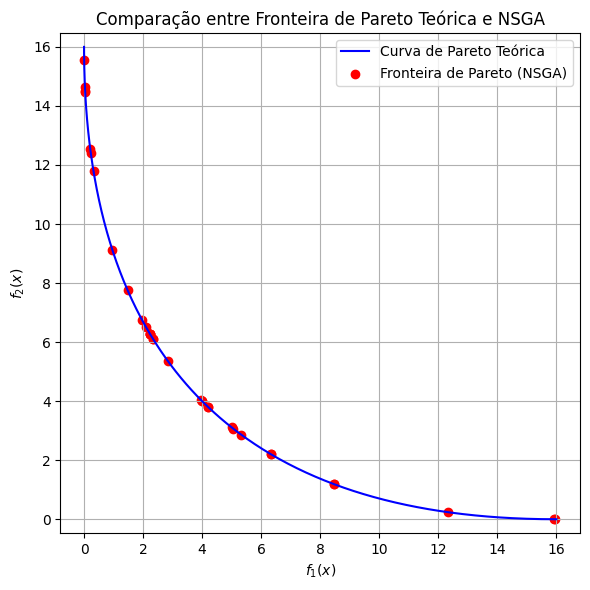

In [25]:
import matplotlib.pyplot as plt

# Executar NSGA
pareto_front = nsga(pop_size=50, generations=10, bounds=(-10, 10))

x_theoretical = np.linspace(-2, 2, 500)
f1_theoretical = f1(x_theoretical)
f2_theoretical = f2(x_theoretical)
        
# Plotando os gráficos
plt.figure(figsize=(6, 6))

# Curva de Pareto no espaço de decisão (x)
plt.plot(f1_theoretical, f2_theoretical, label="Curva de Pareto Teórica", color="blue")
plt.scatter(*zip(*pareto_front), label="Fronteira de Pareto (NSGA)", color="red")
plt.title("Comparação entre Fronteira de Pareto Teórica e NSGA")
plt.xlabel("$f_1(x)$")
plt.ylabel("$f_2(x)$")
plt.legend()
plt.grid()
plt.xticks(np.arange(-2, 20, 2))
plt.yticks(np.arange(-2, 20, 2))
plt.axis("equal")
plt.tight_layout()
plt.show()

## Introdução ao NSGA-II

O **NSGA-II** (*Non-dominated Sorting Genetic Algorithm II*) aprimora o NSGA original por meio de três modificações principais:

1. **Ordenação não dominada mais eficiente**
   O procedimento de classificação das soluções reduz a complexidade computacional de (O(MN^3)) para (O(MN^2)), em que (N) representa o tamanho da população e (M) o número de funções objetivo.

2. **Preservação da diversidade por *crowding distance***
   O mecanismo de *fitness sharing* empregado pelo NSGA original é substituído pela *crowding distance*. Essa métrica estima a densidade de soluções ao redor de cada indivíduo no espaço de objetivos, favorecendo soluções localizadas em regiões menos densamente ocupadas. Com isso, o NSGA-II dispensa a definição de parâmetros de compartilhamento, como o raio (\sigma_{\text{share}}).

3. **Seleção ambiental elitista**
   A população atual é combinada com a população de descendentes. Em seguida, as melhores soluções dessa população conjunta são selecionadas para compor a geração seguinte. Esse procedimento reduz a possibilidade de perda das melhores soluções já encontradas e favorece a convergência em direção à fronteira de Pareto.

### Funcionamento do NSGA-II

1. **Inicialização da população**

   * Gera-se aleatoriamente uma população inicial (P_0) de tamanho (N).
   * Cada indivíduo representa uma solução no espaço de decisão.
   * Todos os indivíduos são avaliados nas funções objetivo do problema.

2. **Ordenação não dominada**

   * A população é classificada em sucessivas fronteiras não dominadas:

     * **Primeira fronteira**: contém as soluções que não são dominadas por nenhuma outra solução da população;
     * **Segunda fronteira**: contém as soluções que se tornam não dominadas após a remoção da primeira fronteira;
     * **Fronteiras seguintes**: são construídas repetindo-se o mesmo procedimento.
   * Cada indivíduo recebe um *rank* correspondente à fronteira à qual pertence. Quanto menor o rank, melhor é sua classificação.

3. **Cálculo da *crowding distance***

   * Para cada fronteira, as soluções são ordenadas separadamente de acordo com cada função objetivo.
   * As soluções extremas recebem distância infinita, de modo que os limites conhecidos da fronteira sejam preservados.
   * Para as demais soluções, a distância é estimada pela soma das diferenças normalizadas entre seus vizinhos mais próximos em cada objetivo.
   * Uma *crowding distance* elevada indica que o indivíduo está localizado em uma região menos densa do espaço de objetivos.

4. **Seleção dos pais**

   * Os pais são selecionados por torneio binário.
   * Dois indivíduos são comparados por meio do operador de comparação do NSGA-II:

     * o indivíduo com menor rank é preferido;
     * se ambos pertencem à mesma fronteira, é preferido aquele com maior *crowding distance*;
     * em caso de empate completo, a escolha pode ser realizada aleatoriamente.
   * Dessa forma, a seleção privilegia simultaneamente a convergência e a diversidade.

5. **Aplicação dos operadores genéticos**

   * **Cruzamento**: combina as características de dois indivíduos selecionados para produzir novos descendentes.
   * **Mutação**: introduz pequenas perturbações aleatórias nos descendentes, aumentando a variabilidade e permitindo a exploração de novas regiões do espaço de decisão.
   * Os operadores genéticos produzem uma população de descendentes $Q_t$, também de tamanho $N$.

6. **Combinação entre pais e descendentes**

   * A população atual (P_t) é combinada com a população de descendentes $Q_t$:

$$
R_t=P_t\cup Q_t.
$$

* A população combinada $R_t$ possui, portanto, até $2N$ indivíduos.
* Todos os indivíduos dessa população são novamente classificados em fronteiras não dominadas.

7. **Seleção ambiental elitista**

   * As fronteiras de $R_t$ são inseridas integralmente na população seguinte, começando pela primeira fronteira.
   * Esse processo continua enquanto a inclusão completa da próxima fronteira não ultrapassar o limite de $N$ indivíduos.
   * Quando a última fronteira considerada não cabe integralmente, seus indivíduos são ordenados por *crowding distance*.
   * As soluções com maiores distâncias são selecionadas até completar a nova população $P_{t+1}$.
   * Como pais e descendentes competem conjuntamente, boas soluções encontradas em gerações anteriores podem ser preservadas.

8. **Iteração**

   * O processo de seleção de pais, cruzamento, mutação, combinação populacional e seleção ambiental é repetido durante várias gerações.
   * Ao longo da evolução, espera-se que a população se aproxime progressivamente da fronteira de Pareto e permaneça distribuída ao longo de suas diferentes regiões.

9. **Resultado**

   * Após o número definido de gerações, a primeira fronteira não dominada da população final é utilizada como aproximação da fronteira de Pareto.
   * Essas soluções representam diferentes compromissos entre os objetivos conflitantes, sem que uma delas seja simultaneamente melhor que as demais em todos os objetivos.

O fluxo principal do NSGA-II pode ser resumido por:

$$
P_t
\longrightarrow
Q_t
\longrightarrow
R_t=P_t\cup Q_t
\longrightarrow
P_{t+1}.
$$

A principal diferença em relação ao NSGA original está na forma de preservar a diversidade e realizar a substituição populacional. Enquanto o NSGA utiliza *fitness sharing* e substituição geracional, o NSGA-II emprega *crowding distance* e seleção ambiental elitista sobre a união entre pais e descendentes.


#### Distância de *Crowding*

Para preservar a diversidade da população, o NSGA-II utiliza a *crowding distance*, uma métrica heurística que estima o grau de isolamento de cada solução no espaço de objetivos. Intuitivamente, quanto maior a *crowding distance* de uma solução, menor é a densidade de soluções em sua vizinhança.

A distância é calculada separadamente dentro de cada fronteira não dominada. Seja $F$ uma fronteira contendo $n$ soluções e seja $M$ o número de funções objetivo. Para cada solução $i \in F$, sua *crowding distance* é inicialmente definida como

$$
d_i = 0.
$$

Em seguida, para cada objetivo $f_m$, com $m = 1,\ldots,M$, as soluções da fronteira são ordenadas em ordem crescente segundo seus valores nesse objetivo:

$$
f_{m,1} \leq f_{m,2} \leq \cdots \leq f_{m,n}.
$$

Nessa ordenação, $f_{m,i}$ representa o valor do objetivo $f_m$ para a solução que ocupa a posição $i$.

Para cada solução interna, isto é, para $i = 2,\ldots,n-1$, a contribuição do objetivo $m$ para a *crowding distance* é dada por

$$
d_i^m =
\frac{
f_{m,i+1} - f_{m,i-1}
}{
f_{m,\max} - f_{m,\min}
},
$$

em que

$$
f_{m,\min} = f_{m,1}
$$

e

$$
f_{m,\max} = f_{m,n}.
$$

A *crowding distance* total da solução corresponde à soma das contribuições calculadas para todos os objetivos:

$$
d_i = \sum_{m=1}^{M} d_i^m.
$$

Assim, uma solução recebe uma distância elevada quando existe uma grande separação entre seus vizinhos no espaço de objetivos. Por outro lado, soluções localizadas em regiões densamente ocupadas tendem a apresentar valores menores de $d_i$.

##### Interpretação dos termos

1. **$f_{m,i}$**

   * Representa o valor da $m$-ésima função objetivo para a solução que ocupa a posição $i$ após a ordenação da fronteira em relação a $f_m$.

2. **$f_{m,i-1}$ e $f_{m,i+1}$**

   * Representam os valores do objetivo $f_m$ para as soluções imediatamente anterior e posterior a $i$ na ordenação associada ao objetivo $m$.

3. **$f_{m,\min}$ e $f_{m,\max}$**

   * Representam, respectivamente, o menor e o maior valor do objetivo $f_m$ dentro da fronteira considerada.

4. **Normalização**

   * A diferença entre os valores dos vizinhos é dividida pela amplitude do objetivo:

$$
f_{m,\max} - f_{m,\min}.
$$

* Essa normalização reduz a influência das diferentes escalas das funções objetivo sobre o cálculo da distância.

#### Casos especiais

##### Soluções extremas

Para cada objetivo $f_m$, as soluções localizadas nas extremidades da ordenação recebem distância infinita:

$$
d_1^m = d_n^m = \infty.
$$

Consequentemente, a distância total dessas soluções também é infinita:

$$
d_1 = d_n = \infty.
$$

Esse procedimento favorece a preservação das soluções extremas da fronteira, evitando que os limites da região conhecida de compromissos sejam eliminados durante a seleção ambiental.

Como a ordenação é realizada separadamente para cada objetivo, uma solução pode ser extrema em um objetivo sem ser extrema nos demais. Basta que ela seja extrema em pelo menos um dos objetivos para que sua *crowding distance* total seja infinita.

##### Fronteiras com até duas soluções

Quando uma fronteira contém uma ou duas soluções, não existem vizinhos suficientes para calcular a expressão baseada nas soluções anterior e posterior. Nesse caso, todas as soluções da fronteira recebem distância infinita:

$$
d_i = \infty,
\qquad
i = 1,\ldots,n,
\qquad
n \leq 2.
$$

##### Objetivos sem variação

Se todas as soluções da fronteira apresentam o mesmo valor para determinado objetivo $f_m$, então

$$
f_{m,\max} - f_{m,\min} = 0.
$$

Nesse caso, o objetivo não fornece informação para distinguir a densidade local das soluções e sua contribuição para as soluções internas deve ser considerada nula:

$$
d_i^m = 0.
$$

Isso também evita uma divisão por zero durante o cálculo.

#### Algoritmo para o cálculo da *crowding distance*

O procedimento pode ser resumido nos seguintes passos:

1. Inicializar a distância de todas as soluções da fronteira:

$$
d_i = 0,
\qquad
i = 1,\ldots,n.
$$

2. Para cada objetivo $f_m$, ordenar as soluções da fronteira de modo que

$$
f_{m,1} \leq f_{m,2} \leq \cdots \leq f_{m,n}.
$$

3. Atribuir distância infinita às soluções extremas da ordenação:

$$
d_1 = d_n = \infty.
$$

4. Para cada solução interna, calcular a contribuição normalizada do objetivo:

$$
d_i^m =
\frac{
f_{m,i+1} - f_{m,i-1}
}{
f_{m,\max} - f_{m,\min}
},
\qquad
i = 2,\ldots,n-1.
$$

5. Acumular essa contribuição na distância total da solução:

$$
d_i \leftarrow d_i + d_i^m.
$$

O procedimento é repetido para todos os $M$ objetivos. Ao final, soluções com maior *crowding distance* são consideradas preferíveis quando comparadas a outras soluções pertencentes à mesma fronteira, pois representam regiões menos densamente ocupadas do espaço de objetivos.

A seguir, apresentamos uma implementação didática do NSGA-II, destacando a ordenação não dominada, o cálculo da *crowding distance*, a seleção por torneio e a seleção ambiental elitista.


In [27]:
import random
import numpy as np


def nsga2(
    pop_size,
    generations,
    bounds,
    mutation_rate=0.2,
    mutation_scale=0.05,
):
    """
    Implementação didática do NSGA-II.

    Características:
    - ordenação rápida em fronteiras não dominadas;
    - classificação dos indivíduos por rank de dominância;
    - crowding distance para preservação da diversidade;
    - seleção de pais por torneio binário;
    - elitismo por meio da união entre pais e descendentes;
    - seleção ambiental baseada em rank e crowding distance.

    Parâmetros
    ----------
    pop_size : int
        Número de indivíduos da população.

    generations : int
        Número de gerações.

    bounds : tuple[float, float]
        Limites inferior e superior da variável de decisão.

    mutation_rate : float
        Probabilidade de mutação de cada descendente.

    mutation_scale : float
        Intensidade máxima da mutação, expressa como uma fração
        do intervalo da variável de decisão.
    """

    lower_bound, upper_bound = bounds
    decision_range = upper_bound - lower_bound

    if pop_size < 2:
        raise ValueError("pop_size deve ser pelo menos 2.")

    if decision_range <= 0:
        raise ValueError(
            "O limite superior deve ser maior que o limite inferior."
        )

    # ── Inicialização ──────────────────────────────────────────────────────────

    def initialize_population(size):
        """
        Gera uma população inicial aleatória dentro dos limites
        da variável de decisão.
        """
        return [
            random.uniform(lower_bound, upper_bound)
            for _ in range(size)
        ]

    # ── Avaliação ──────────────────────────────────────────────────────────────

    def evaluate_population(population):
        """
        Avalia todos os indivíduos nas funções objetivo.
        """
        return [
            (f1(individual), f2(individual))
            for individual in population
        ]

    # ── Dominância de Pareto ───────────────────────────────────────────────────

    def dominates(objectives_a, objectives_b):
        """
        Retorna True quando A domina B em um problema de minimização.

        Para isso, A deve:
        - não ser pior que B em nenhum objetivo;
        - ser estritamente melhor que B em pelo menos um objetivo.
        """
        no_worse = all(
            value_a <= value_b
            for value_a, value_b in zip(
                objectives_a,
                objectives_b,
            )
        )

        strictly_better = any(
            value_a < value_b
            for value_a, value_b in zip(
                objectives_a,
                objectives_b,
            )
        )

        return no_worse and strictly_better

    # ── Ordenação rápida não dominada ──────────────────────────────────────────

    def fast_nondominated_sort(objectives):
        """
        Classifica os indivíduos em fronteiras não dominadas.

        fronts[0] contém as soluções não dominadas da população.
        fronts[1] contém as soluções de rank 1, e assim sucessivamente.

        Retorna
        -------
        fronts : list[list[int]]
            Índices dos indivíduos em cada fronteira.

        ranks : list[int]
            Rank de dominância de cada indivíduo.
        """
        population_size = len(objectives)

        domination_count = [0] * population_size

        dominated_solutions = [
            [] for _ in range(population_size)
        ]

        ranks = [0] * population_size
        fronts = [[]]

        # Compara todas as soluções duas a duas.
        for p in range(population_size):
            for q in range(population_size):
                if p == q:
                    continue

                if dominates(objectives[p], objectives[q]):
                    dominated_solutions[p].append(q)

                elif dominates(objectives[q], objectives[p]):
                    domination_count[p] += 1

            # Soluções não dominadas pertencem à primeira fronteira.
            if domination_count[p] == 0:
                ranks[p] = 0
                fronts[0].append(p)

        # Constrói as fronteiras seguintes.
        current_front_index = 0

        while fronts[current_front_index]:
            next_front = []

            for p in fronts[current_front_index]:
                for q in dominated_solutions[p]:
                    domination_count[q] -= 1

                    if domination_count[q] == 0:
                        ranks[q] = current_front_index + 1
                        next_front.append(q)

            current_front_index += 1
            fronts.append(next_front)

        # Remove a última fronteira vazia.
        fronts.pop()

        return fronts, ranks

    # ── Crowding distance ──────────────────────────────────────────────────────

    def crowding_distance(front, objectives):
        """
        Calcula a crowding distance dos indivíduos de uma fronteira.

        A crowding distance estima o espaço disponível ao redor de cada
        solução no espaço de objetivos.

        Valores maiores indicam soluções localizadas em regiões menos
        densas da fronteira.
        """
        distances = {
            individual_index: 0.0
            for individual_index in front
        }

        if not front:
            return distances

        # Em uma fronteira com até dois indivíduos, todos são extremos.
        if len(front) <= 2:
            for individual_index in front:
                distances[individual_index] = float("inf")

            return distances

        number_of_objectives = len(objectives[0])

        for objective_index in range(number_of_objectives):
            sorted_front = sorted(
                front,
                key=lambda individual_index: objectives[
                    individual_index
                ][objective_index],
            )

            minimum_value = objectives[
                sorted_front[0]
            ][objective_index]

            maximum_value = objectives[
                sorted_front[-1]
            ][objective_index]

            objective_range = maximum_value - minimum_value

            # Se todas as soluções possuem o mesmo valor nesse objetivo,
            # ele não contribui para a crowding distance.
            if objective_range == 0:
                continue

            # As soluções extremas são sempre preservadas.
            distances[sorted_front[0]] = float("inf")
            distances[sorted_front[-1]] = float("inf")

            # Distância normalizada entre os vizinhos mais próximos.
            for position in range(1, len(sorted_front) - 1):
                current_index = sorted_front[position]

                previous_index = sorted_front[position - 1]
                next_index = sorted_front[position + 1]

                previous_value = objectives[
                    previous_index
                ][objective_index]

                next_value = objectives[
                    next_index
                ][objective_index]

                distances[current_index] += (
                    next_value - previous_value
                ) / objective_range

        return distances

    def calculate_population_crowding(fronts, objectives):
        """
        Calcula a crowding distance de todos os indivíduos da população.
        """
        distances = [0.0] * len(objectives)

        for front in fronts:
            front_distances = crowding_distance(
                front,
                objectives,
            )

            for individual_index, distance in front_distances.items():
                distances[individual_index] = distance

        return distances

    # ── Operador de comparação do NSGA-II ──────────────────────────────────────

    def crowded_comparison(
        individual_a,
        individual_b,
        ranks,
        distances,
    ):
        """
        Implementa o crowded-comparison operator do NSGA-II.

        O indivíduo A é preferido em relação a B quando:

        1. A possui menor rank de dominância; ou
        2. ambos possuem o mesmo rank, mas A possui maior
           crowding distance.
        """
        if ranks[individual_a] < ranks[individual_b]:
            return individual_a

        if ranks[individual_b] < ranks[individual_a]:
            return individual_b

        if distances[individual_a] > distances[individual_b]:
            return individual_a

        if distances[individual_b] > distances[individual_a]:
            return individual_b

        # Empate completo.
        return random.choice(
            [individual_a, individual_b]
        )

    # ── Seleção dos pais ───────────────────────────────────────────────────────

    def binary_tournament_selection(
        population,
        ranks,
        distances,
    ):
        """
        Seleciona um pai por torneio binário.

        Dois indivíduos são escolhidos aleatoriamente, e o melhor deles
        é determinado pelo operador de comparação do NSGA-II.
        """
        candidate_a, candidate_b = random.sample(
            range(len(population)),
            2,
        )

        winner = crowded_comparison(
            candidate_a,
            candidate_b,
            ranks,
            distances,
        )

        return population[winner]

    # ── Operadores genéticos ───────────────────────────────────────────────────

    def crossover(parent1, parent2):
        """
        Cruzamento aritmético.

        Produz dois descendentes complementares a partir dos pais.
        """
        beta = random.random()

        child1 = (
            beta * parent1
            + (1.0 - beta) * parent2
        )

        child2 = (
            (1.0 - beta) * parent1
            + beta * parent2
        )

        return child1, child2

    def mutate(individual):
        """
        Adiciona uma perturbação uniforme ao indivíduo.

        Após a mutação, o valor é limitado ao intervalo definido
        pelo problema.
        """
        if random.random() < mutation_rate:
            maximum_step = mutation_scale * decision_range

            individual += random.uniform(
                -maximum_step,
                maximum_step,
            )

        return float(
            np.clip(
                individual,
                lower_bound,
                upper_bound,
            )
        )

    def create_offspring(
        population,
        ranks,
        distances,
    ):
        """
        Gera uma população de descendentes.

        Os pais são selecionados por torneio binário, considerando
        primeiramente o rank e, em caso de empate, a crowding distance.
        """
        offspring = []

        while len(offspring) < pop_size:
            parent1 = binary_tournament_selection(
                population,
                ranks,
                distances,
            )

            parent2 = binary_tournament_selection(
                population,
                ranks,
                distances,
            )

            child1, child2 = crossover(
                parent1,
                parent2,
            )

            offspring.append(mutate(child1))

            if len(offspring) < pop_size:
                offspring.append(mutate(child2))

        return offspring

    # ── Seleção ambiental elitista ─────────────────────────────────────────────

    def select_next_population(
        combined_population,
        combined_objectives,
        combined_fronts,
    ):
        """
        Seleciona a próxima população a partir da união entre pais
        e descendentes.

        As fronteiras são adicionadas integralmente enquanto houver
        espaço. Quando uma fronteira não cabe por completo, seus
        indivíduos são ordenados por crowding distance.
        """
        next_population = []

        for front in combined_fronts:
            available_positions = (
                pop_size - len(next_population)
            )

            if available_positions == 0:
                break

            # A fronteira inteira cabe na próxima população.
            if len(front) <= available_positions:
                next_population.extend(
                    combined_population[individual_index]
                    for individual_index in front
                )

            else:
                # Apenas parte da fronteira pode ser preservada.
                distances = crowding_distance(
                    front,
                    combined_objectives,
                )

                ordered_front = sorted(
                    front,
                    key=lambda individual_index: distances[
                        individual_index
                    ],
                    reverse=True,
                )

                selected_indices = ordered_front[
                    :available_positions
                ]

                next_population.extend(
                    combined_population[individual_index]
                    for individual_index in selected_indices
                )

                break

        return next_population

    # ── Evolução ───────────────────────────────────────────────────────────────

    population = initialize_population(pop_size)

    for generation in range(generations):
        # 1. Avalia e classifica a população atual.
        objectives = evaluate_population(population)

        fronts, ranks = fast_nondominated_sort(
            objectives
        )

        distances = calculate_population_crowding(
            fronts,
            objectives,
        )

        # 2. Produz os descendentes por torneio, cruzamento e mutação.
        offspring = create_offspring(
            population,
            ranks,
            distances,
        )

        # 3. Combina pais e descendentes.
        combined_population = population + offspring

        combined_objectives = evaluate_population(
            combined_population
        )

        # 4. Ordena a população combinada em fronteiras.
        combined_fronts, _ = fast_nondominated_sort(
            combined_objectives
        )

        # 5. Seleciona elitistamente a próxima geração.
        population = select_next_population(
            combined_population,
            combined_objectives,
            combined_fronts,
        )

    # ── Resultado final ────────────────────────────────────────────────────────

    objectives = evaluate_population(population)

    fronts, _ = fast_nondominated_sort(objectives)

    pareto_front = [
        objectives[individual_index]
        for individual_index in fronts[0]
    ]

    pareto_front.sort(
        key=lambda point: point[0]
    )

    return pareto_front

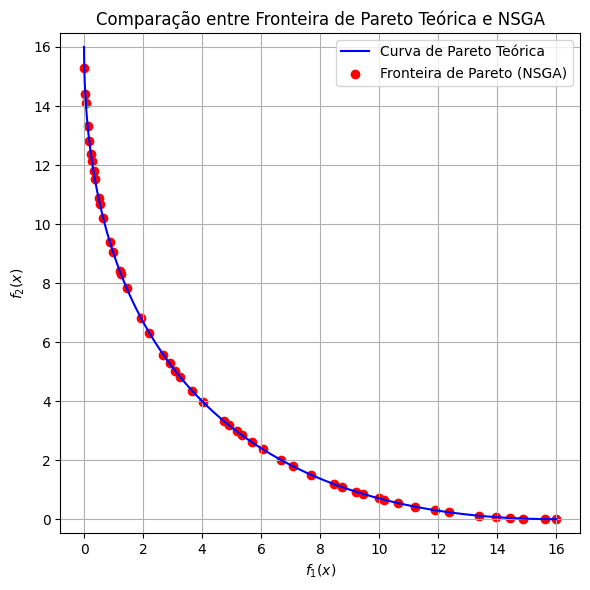

In [29]:
import matplotlib.pyplot as plt

# Executar NSGA-II
pareto_front = nsga2(pop_size=50, generations=10, bounds=(-10, 10))

x_theoretical = np.linspace(-2, 2, 500)
f1_theoretical = f1(x_theoretical)
f2_theoretical = f2(x_theoretical)
        
# Plotando os gráficos
plt.figure(figsize=(6, 6))

# Curva de Pareto no espaço de decisão (x)
plt.plot(f1_theoretical, f2_theoretical, label="Curva de Pareto Teórica", color="blue")
plt.scatter(*zip(*pareto_front), label="Fronteira de Pareto (NSGA)", color="red")
plt.title("Comparação entre Fronteira de Pareto Teórica e NSGA")
plt.xlabel("$f_1(x)$")
plt.ylabel("$f_2(x)$")
plt.legend()
plt.grid()
plt.xticks(np.arange(-2, 20, 2))
plt.yticks(np.arange(-2, 20, 2))
plt.axis("equal")
plt.tight_layout()
plt.show()

## NSGA-III

O NSGA-III (Non-dominated Sorting Genetic Algorithm III) é uma extensão do NSGA-II, projetado para otimização multiobjetivo com um número maior de objetivos (tipicamente mais de três). Enquanto o NSGA-II utiliza a distância de crowding para manter a diversidade na população, o NSGA-III introduz um método baseado em pontos de referência (reference points) e nichos para melhorar a distribuição das soluções ao longo da fronteira de Pareto, especialmente em problemas de alta dimensionalidade.

No código a seguir, adaptamos o algoritmo NSGA-III para um problema com dois objetivos para fins ilustrativos, embora o NSGA-III seja mais eficaz em problemas com mais objetivos. As modificações feitas asseguram que o algoritmo funcione corretamente, evitando loops infinitos e melhorando a eficiência computacional.

In [30]:
import math
import random
import numpy as np


def nsga3(
    pop_size,
    generations,
    bounds,
    divisions=None,
    mutation_rate=0.2,
    mutation_scale=0.05,
):
    """
    Implementação didática do NSGA-III.

    Características:
    - ordenação rápida em fronteiras não dominadas;
    - seleção ambiental elitista;
    - geração de pontos de referência pelo método de Das e Dennis;
    - normalização adaptativa dos objetivos;
    - associação das soluções aos pontos de referência;
    - preservação da diversidade por niching;
    - não utiliza crowding distance.

    Parâmetros
    ----------
    pop_size : int
        Número de indivíduos da população.

    generations : int
        Número de gerações.

    bounds : tuple[float, float]
        Limites inferior e superior da variável de decisão.

    divisions : int | None
        Número de divisões p utilizado para gerar os pontos de referência.

        Para M objetivos, o número de pontos gerados é

            H = comb(M + p - 1, p).

        Quando divisions=None, escolhe-se automaticamente um valor de p
        que produz uma quantidade de pontos próxima de pop_size.

    mutation_rate : float
        Probabilidade de mutação de cada descendente.

    mutation_scale : float
        Intensidade máxima da mutação, expressa como fração do
        intervalo da variável de decisão.
    """

    lower_bound, upper_bound = bounds
    decision_range = upper_bound - lower_bound

    if pop_size < 2:
        raise ValueError("pop_size deve ser pelo menos 2.")

    if generations < 1:
        raise ValueError("generations deve ser pelo menos 1.")

    if decision_range <= 0:
        raise ValueError(
            "O limite superior deve ser maior que o limite inferior."
        )

    if divisions is not None and divisions < 1:
        raise ValueError("divisions deve ser um inteiro positivo.")

    # Para acrescentar novos objetivos, basta incluí-los nesta tupla.
    objective_functions = (f1, f2)

    number_of_objectives = len(objective_functions)

    # ── Inicialização ──────────────────────────────────────────────────────────

    def initialize_population(size):
        """
        Gera uma população inicial aleatória no espaço de decisão.
        """
        return [
            random.uniform(lower_bound, upper_bound)
            for _ in range(size)
        ]

    # ── Avaliação ──────────────────────────────────────────────────────────────

    def evaluate_population(population):
        """
        Avalia todos os indivíduos nas funções objetivo.
        """
        return [
            tuple(
                objective_function(individual)
                for objective_function in objective_functions
            )
            for individual in population
        ]

    # ── Dominância de Pareto ───────────────────────────────────────────────────

    def dominates(objectives_a, objectives_b):
        """
        Retorna True quando A domina B em um problema de minimização.

        A deve:
        - não ser pior que B em nenhum objetivo;
        - ser estritamente melhor que B em pelo menos um objetivo.
        """
        no_worse = all(
            value_a <= value_b
            for value_a, value_b in zip(
                objectives_a,
                objectives_b,
            )
        )

        strictly_better = any(
            value_a < value_b
            for value_a, value_b in zip(
                objectives_a,
                objectives_b,
            )
        )

        return no_worse and strictly_better

    # ── Ordenação rápida não dominada ──────────────────────────────────────────

    def fast_nondominated_sort(objectives):
        """
        Classifica os indivíduos em fronteiras não dominadas.

        fronts[0] contém as soluções não dominadas.
        fronts[1] contém as soluções de rank 1, e assim sucessivamente.

        Retorna
        -------
        fronts : list[list[int]]
            Índices dos indivíduos pertencentes a cada fronteira.

        ranks : list[int]
            Rank de dominância de cada indivíduo.
        """
        population_size = len(objectives)

        domination_count = [0] * population_size

        dominated_solutions = [
            [] for _ in range(population_size)
        ]

        ranks = [0] * population_size
        fronts = [[]]

        # Compara cada par de soluções apenas uma vez.
        for p in range(population_size):
            for q in range(p + 1, population_size):

                if dominates(objectives[p], objectives[q]):
                    dominated_solutions[p].append(q)
                    domination_count[q] += 1

                elif dominates(objectives[q], objectives[p]):
                    dominated_solutions[q].append(p)
                    domination_count[p] += 1

        # Identifica a primeira fronteira.
        for p in range(population_size):
            if domination_count[p] == 0:
                ranks[p] = 0
                fronts[0].append(p)

        # Constrói as fronteiras seguintes.
        current_front_index = 0

        while (
            current_front_index < len(fronts)
            and fronts[current_front_index]
        ):
            next_front = []

            for p in fronts[current_front_index]:
                for q in dominated_solutions[p]:
                    domination_count[q] -= 1

                    if domination_count[q] == 0:
                        ranks[q] = current_front_index + 1
                        next_front.append(q)

            if next_front:
                fronts.append(next_front)

            current_front_index += 1

        return fronts, ranks

    # ── Pontos de referência ───────────────────────────────────────────────────

    def number_of_reference_points(
        number_of_objectives,
        number_of_divisions,
    ):
        """
        Calcula a quantidade de pontos de referência:

            H = C(M + p - 1, p).
        """
        return math.comb(
            number_of_objectives + number_of_divisions - 1,
            number_of_divisions,
        )

    def infer_number_of_divisions(
        number_of_objectives,
        target_number,
    ):
        """
        Escolhe o valor de p que gera uma quantidade de pontos de
        referência próxima do tamanho da população.
        """
        p = 1

        while (
            number_of_reference_points(
                number_of_objectives,
                p,
            )
            < target_number
        ):
            p += 1

        candidates = [p]

        if p > 1:
            candidates.append(p - 1)

        return min(
            candidates,
            key=lambda candidate: abs(
                number_of_reference_points(
                    number_of_objectives,
                    candidate,
                )
                - target_number
            ),
        )

    def generate_reference_points(
        number_of_objectives,
        number_of_divisions,
    ):
        """
        Gera pontos uniformemente distribuídos sobre o simplex unitário:

            z_1 + z_2 + ... + z_M = 1

        com

            z_m >= 0.

        O método enumera todas as composições inteiras de p em M partes
        e divide cada coordenada por p.
        """
        reference_points = []

        current_point = [0] * number_of_objectives

        def generate_coordinate(
            coordinate_index,
            remaining_divisions,
        ):
            # A última coordenada recebe todo o valor restante.
            if coordinate_index == number_of_objectives - 1:
                current_point[coordinate_index] = (
                    remaining_divisions
                )

                reference_points.append(
                    np.asarray(
                        current_point,
                        dtype=float,
                    )
                    / number_of_divisions
                )

                return

            for value in range(remaining_divisions + 1):
                current_point[coordinate_index] = value

                generate_coordinate(
                    coordinate_index + 1,
                    remaining_divisions - value,
                )

        generate_coordinate(
            coordinate_index=0,
            remaining_divisions=number_of_divisions,
        )

        return np.vstack(reference_points)

    # ── Normalização dos objetivos ─────────────────────────────────────────────

    def normalize_objectives(
        objectives,
        considered_indices,
    ):
        """
        Normaliza os objetivos das soluções consideradas na seleção
        ambiental.

        O procedimento realiza:

        1. identificação do ponto ideal;
        2. translação dos objetivos;
        3. identificação dos pontos extremos por ASF;
        4. cálculo dos interceptos do hiperplano;
        5. normalização pelos interceptos.

        Em casos degenerados, utiliza-se a amplitude observada em cada
        objetivo como alternativa aos interceptos.
        """
        values = np.asarray(
            [
                objectives[individual_index]
                for individual_index in considered_indices
            ],
            dtype=float,
        )

        # 1. Ponto ideal.
        ideal_point = np.min(values, axis=0)

        # 2. Translação: o ponto ideal é levado à origem.
        translated_values = values - ideal_point

        epsilon = 1.0e-12

        # 3. Determinação dos pontos extremos por ASF.
        extreme_points = []

        for objective_index in range(number_of_objectives):
            weights = np.full(
                number_of_objectives,
                1.0e-6,
            )

            weights[objective_index] = 1.0

            asf_values = np.max(
                translated_values / weights,
                axis=1,
            )

            extreme_point_index = int(
                np.argmin(asf_values)
            )

            extreme_points.append(
                translated_values[extreme_point_index]
            )

        extreme_points = np.asarray(
            extreme_points,
            dtype=float,
        )

        # 4. Cálculo dos interceptos do hiperplano.
        use_fallback = False

        try:
            hyperplane_coefficients = np.linalg.solve(
                extreme_points,
                np.ones(number_of_objectives),
            )

            intercepts = (
                1.0 / hyperplane_coefficients
            )

            if (
                not np.all(np.isfinite(intercepts))
                or np.any(intercepts <= epsilon)
            ):
                use_fallback = True

        except np.linalg.LinAlgError:
            # Os pontos extremos podem formar uma matriz singular.
            use_fallback = True

        if use_fallback:
            # Alternativa robusta para casos degenerados.
            intercepts = np.max(
                translated_values,
                axis=0,
            )

        # Evita divisão por zero em objetivos sem variação.
        intercepts = np.where(
            intercepts > epsilon,
            intercepts,
            1.0,
        )

        # 5. Normalização.
        normalized_values = (
            translated_values / intercepts
        )

        return normalized_values

    # ── Associação aos pontos de referência ────────────────────────────────────

    def associate_to_reference_points(
        normalized_values,
        reference_points,
    ):
        """
        Associa cada solução normalizada à direção de referência mais
        próxima.

        A proximidade é medida pela distância perpendicular entre a
        solução e a reta que parte da origem na direção do ponto de
        referência.

        Retorna
        -------
        associations : list[int]
            Índice do ponto de referência associado a cada solução.

        distances : list[float]
            Distância perpendicular ao ponto de referência associado.
        """
        squared_reference_norms = np.sum(
            reference_points * reference_points,
            axis=1,
        )

        associations = []
        distances = []

        for point in normalized_values:

            # Projeção de point sobre cada direção de referência.
            projection_factors = (
                reference_points @ point
            ) / squared_reference_norms

            projected_points = (
                projection_factors[:, np.newaxis]
                * reference_points
            )

            perpendicular_distances = np.linalg.norm(
                point - projected_points,
                axis=1,
            )

            associated_reference = int(
                np.argmin(perpendicular_distances)
            )

            associations.append(
                associated_reference
            )

            distances.append(
                float(
                    perpendicular_distances[
                        associated_reference
                    ]
                )
            )

        return associations, distances

    # ── Operadores genéticos ───────────────────────────────────────────────────

    def crossover(parent1, parent2):
        """
        Cruzamento aritmético.

        Produz dois descendentes complementares.
        """
        beta = random.random()

        child1 = (
            beta * parent1
            + (1.0 - beta) * parent2
        )

        child2 = (
            (1.0 - beta) * parent1
            + beta * parent2
        )

        return child1, child2

    def mutate(individual):
        """
        Adiciona uma perturbação uniforme e mantém o indivíduo dentro
        dos limites do problema.
        """
        if random.random() < mutation_rate:
            maximum_step = (
                mutation_scale * decision_range
            )

            individual += random.uniform(
                -maximum_step,
                maximum_step,
            )

        return float(
            np.clip(
                individual,
                lower_bound,
                upper_bound,
            )
        )

    def create_offspring(population):
        """
        Gera a população de descendentes.

        Nesta implementação, os pais são escolhidos aleatoriamente,
        seguindo a formulação original do NSGA-III, na qual a principal
        pressão seletiva é aplicada durante a seleção ambiental.
        """
        offspring = []

        while len(offspring) < pop_size:
            parent1, parent2 = random.sample(
                population,
                2,
            )

            child1, child2 = crossover(
                parent1,
                parent2,
            )

            offspring.append(
                mutate(child1)
            )

            if len(offspring) < pop_size:
                offspring.append(
                    mutate(child2)
                )

        return offspring

    # ── Seleção por nichos ─────────────────────────────────────────────────────

    def niching_selection(
        accepted_indices,
        last_front,
        objectives,
        reference_points,
        number_to_select,
    ):
        """
        Seleciona soluções da última fronteira por meio do mecanismo
        de niching do NSGA-III.

        Parâmetros
        ----------
        accepted_indices : list[int]
            Soluções das fronteiras já aceitas integralmente.

        last_front : list[int]
            Última fronteira, que não cabe integralmente na população.

        objectives : list[tuple]
            Valores das funções objetivo da população combinada.

        reference_points : numpy.ndarray
            Pontos de referência utilizados pelo algoritmo.

        number_to_select : int
            Número de soluções que ainda devem ser selecionadas.
        """

        # S_t contém as fronteiras completas e a última fronteira.
        considered_indices = (
            accepted_indices + last_front
        )

        normalized_values = normalize_objectives(
            objectives,
            considered_indices,
        )

        associations, distances = (
            associate_to_reference_points(
                normalized_values,
                reference_points,
            )
        )

        # Relaciona o índice global da solução à sua posição em S_t.
        position_in_considered_set = {
            individual_index: position
            for position, individual_index
            in enumerate(considered_indices)
        }

        number_of_references = len(reference_points)

        # rho_j: quantidade de soluções já aceitas associadas a j.
        niche_counts = [0] * number_of_references

        for individual_index in accepted_indices:
            position = position_in_considered_set[
                individual_index
            ]

            reference_index = associations[position]

            niche_counts[reference_index] += 1

        # Soluções da última fronteira agrupadas pelo ponto de referência.
        candidates_by_reference = {
            reference_index: []
            for reference_index in range(
                number_of_references
            )
        }

        for individual_index in last_front:
            position = position_in_considered_set[
                individual_index
            ]

            reference_index = associations[position]

            distance = distances[position]

            candidates_by_reference[
                reference_index
            ].append(
                (individual_index, distance)
            )

        selected_indices = []

        # Apenas referências com candidatos precisam ser consideradas.
        active_references = {
            reference_index
            for reference_index, candidates
            in candidates_by_reference.items()
            if candidates
        }

        while (
            len(selected_indices) < number_to_select
            and active_references
        ):
            # Identifica o menor número de nicho entre as referências ativas.
            minimum_niche_count = min(
                niche_counts[reference_index]
                for reference_index in active_references
            )

            least_occupied_references = [
                reference_index
                for reference_index in active_references
                if niche_counts[reference_index]
                == minimum_niche_count
            ]

            # Em caso de empate, escolhe-se uma referência aleatoriamente.
            chosen_reference = random.choice(
                least_occupied_references
            )

            candidates = candidates_by_reference[
                chosen_reference
            ]

            if niche_counts[chosen_reference] == 0:
                # Se o nicho ainda estiver vazio, seleciona-se a solução
                # mais próxima da direção de referência.
                minimum_distance = min(
                    distance
                    for _, distance in candidates
                )

                closest_candidates = [
                    candidate
                    for candidate in candidates
                    if np.isclose(
                        candidate[1],
                        minimum_distance,
                    )
                ]

                chosen_candidate = random.choice(
                    closest_candidates
                )

            else:
                # Se o nicho já contém soluções, qualquer candidato
                # associado pode ser escolhido.
                chosen_candidate = random.choice(
                    candidates
                )

            chosen_index, _ = chosen_candidate

            selected_indices.append(
                chosen_index
            )

            candidates.remove(
                chosen_candidate
            )

            niche_counts[chosen_reference] += 1

            # A referência deixa de participar quando não possui candidatos.
            if not candidates:
                active_references.remove(
                    chosen_reference
                )

        # Salvaguarda: preenche posições eventualmente restantes.
        if len(selected_indices) < number_to_select:
            selected_set = set(selected_indices)

            remaining_candidates = [
                individual_index
                for individual_index in last_front
                if individual_index not in selected_set
            ]

            random.shuffle(remaining_candidates)

            missing = (
                number_to_select
                - len(selected_indices)
            )

            selected_indices.extend(
                remaining_candidates[:missing]
            )

        return selected_indices

    # ── Seleção ambiental elitista ─────────────────────────────────────────────

    def select_next_population(
        combined_population,
        combined_objectives,
        combined_fronts,
        reference_points,
    ):
        """
        Seleciona a próxima geração a partir da união entre pais e
        descendentes.

        As fronteiras são adicionadas integralmente enquanto houver
        espaço. Quando uma fronteira não cabe por completo, as posições
        restantes são preenchidas pelo mecanismo de niching.
        """
        accepted_indices = []
        last_front = None

        for front in combined_fronts:

            if (
                len(accepted_indices) + len(front)
                <= pop_size
            ):
                accepted_indices.extend(front)

                if len(accepted_indices) == pop_size:
                    return [
                        combined_population[individual_index]
                        for individual_index
                        in accepted_indices
                    ]

            else:
                last_front = list(front)
                break

        if last_front is None:
            return [
                combined_population[individual_index]
                for individual_index
                in accepted_indices[:pop_size]
            ]

        number_to_select = (
            pop_size - len(accepted_indices)
        )

        selected_from_last_front = niching_selection(
            accepted_indices=accepted_indices,
            last_front=last_front,
            objectives=combined_objectives,
            reference_points=reference_points,
            number_to_select=number_to_select,
        )

        next_population_indices = (
            accepted_indices
            + selected_from_last_front
        )

        return [
            combined_population[individual_index]
            for individual_index
            in next_population_indices
        ]

    # ── Preparação dos pontos de referência ────────────────────────────────────

    if divisions is None:
        number_of_divisions = (
            infer_number_of_divisions(
                number_of_objectives,
                pop_size,
            )
        )
    else:
        number_of_divisions = divisions

    reference_points = generate_reference_points(
        number_of_objectives,
        number_of_divisions,
    )

    # ── Evolução ───────────────────────────────────────────────────────────────

    population = initialize_population(pop_size)

    for generation in range(generations):

        # 1. Gera uma população de descendentes Q_t.
        offspring = create_offspring(
            population
        )

        # 2. Combina pais e descendentes.
        combined_population = (
            population + offspring
        )

        # 3. Avalia a população combinada R_t.
        combined_objectives = evaluate_population(
            combined_population
        )

        # 4. Classifica R_t em fronteiras não dominadas.
        combined_fronts, _ = (
            fast_nondominated_sort(
                combined_objectives
            )
        )

        # 5. Seleciona elitistamente P_{t+1}.
        population = select_next_population(
            combined_population=combined_population,
            combined_objectives=combined_objectives,
            combined_fronts=combined_fronts,
            reference_points=reference_points,
        )

    # ── Resultado final ────────────────────────────────────────────────────────

    objectives = evaluate_population(
        population
    )

    fronts, _ = fast_nondominated_sort(
        objectives
    )

    pareto_front = [
        objectives[individual_index]
        for individual_index in fronts[0]
    ]

    pareto_front.sort(
        key=lambda point: point[0]
    )

    return pareto_front

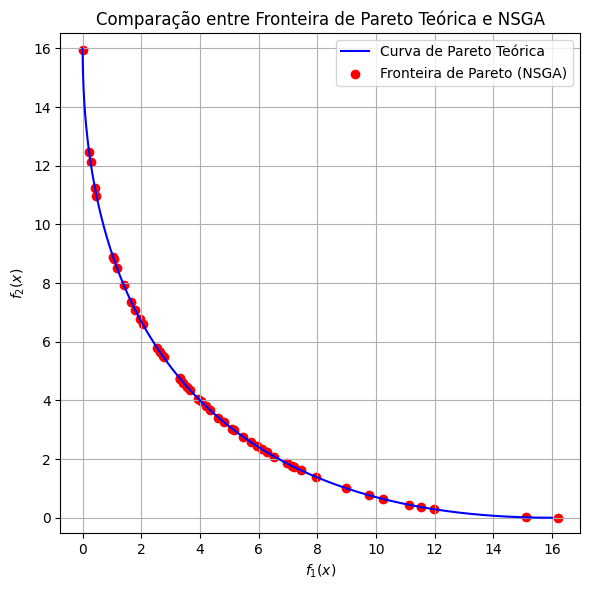

In [ ]:
import matplotlib.pyplot as plt

# Executar NSGA-III
pareto_front = nsga3(pop_size=50, generations=10, bounds=(-10, 10), divisions=10)

x_theoretical = np.linspace(-2, 2, 500)
f1_theoretical = f1(x_theoretical)
f2_theoretical = f2(x_theoretical)
        
# Plotando os gráficos
plt.figure(figsize=(6, 6))

# Curva de Pareto no espaço de decisão (x)
plt.plot(f1_theoretical, f2_theoretical, label="Curva de Pareto Teórica", color="blue")
plt.scatter(*zip(*pareto_front), label="Fronteira de Pareto (NSGA-III)", color="red")
plt.title("Comparação entre Fronteira de Pareto Teórica e NSGA-III")
plt.xlabel("$f_1(x)$")
plt.ylabel("$f_2(x)$")
plt.legend()
plt.grid()
plt.xticks(np.arange(-2, 20, 2))
plt.yticks(np.arange(-2, 20, 2))
plt.axis("equal")
plt.tight_layout()
plt.show()

### Resumo da família de algoritmos NSGA

Cada versão do algoritmo NSGA traz avanços importantes:

- **NSGA**: Foi inovador ao introduzir o conceito de ordenamento não dominado e função de compartilhamento para diversidade, mas sofreu com limitações de complexidade e falta de elitismo.
- **NSGA-II**: Tornou o algoritmo mais eficiente e robusto com a introdução do elitismo e da distância de aglomeração, tornando-se o padrão para otimização multiobjetivo com até três objetivos.
- **NSGA-III**: Ampliou as capacidades do NSGA-II para problemas de muitos objetivos, com uma abordagem baseada em pontos de referência que garante uma boa distribuição de soluções na fronteira de Pareto.

As diferenças entre as três versões refletem a evolução no desenvolvimento de algoritmos evolutivos multiobjetivo. A tabela a seguir apresenta um comparativo geral:


| Característica           | NSGA                          | NSGA-II                    | NSGA-III                                        |
| ------------------------ | ----------------------------- | -------------------------- | ----------------------------------------------- |
| Ordenamento Não Dominado | $O(MN^3)$, sem elitismo       | $O(MN^2)$, com elitismo    | $O(MN^2)$, com elitismo e pontos de referência  |
| Diversidade              | Função de Compartilhamento    | Distância de Aglomeração   | Distância de Aglomeração e Pontos de Referência |
| Eficiência Computacional | Baixa                         | Alta para poucos objetivos | Moderada, com ajuste de pontos de referência    |
| Aplicabilidade           | Problemas de poucos objetivos | Até três objetivos         | Muitos objetivos (alta dimensionalidade)        |



## Referências

**K. Deb, A. Pratap, S. Agarwal, and T. Meyarivan**, *"A Fast and Elitist Multiobjective Genetic Algorithm: NSGA-II,"* IEEE Transactions on Evolutionary Computation, vol. 6, no. 2, pp. 182–197, Apr. 2002.

**K. Deb and H. Jain**, *"An Evolutionary Many-Objective Optimization Algorithm Using Reference-Point-Based Nondominated Sorting Approach, Part I: Solving Problems With Box Constraints,"* in IEEE Transactions on Evolutionary Computation, vol. 18, no. 4, pp. 577–601, Aug. 2014.

**K. Deb**, *"Multi-Objective Optimization Using Evolutionary Algorithms,"* John Wiley & Sons, 2001.
